Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [2]:
#Dimensiones de la imagen a crear
ancho = 300
alto = 200

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

In [2]:
ancho_chess = 800
alto_chess = 800
tamaño_casilla = 100

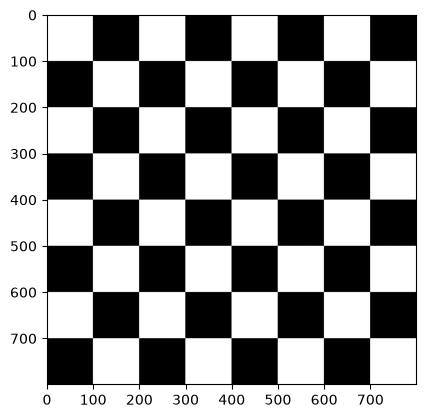

In [33]:
gris_img = np.zeros((ancho_chess,alto_chess,1), dtype = np.uint8)

casillas = int(ancho_chess / tamaño_casilla)

for fila in range(casillas):
    if fila % 2 == 0:
        for columna in range(casillas): 
            if columna % 2 == 0:
                gris_img[(fila*tamaño_casilla):(fila*tamaño_casilla+tamaño_casilla),(columna*tamaño_casilla):(columna*tamaño_casilla+tamaño_casilla),0] = 255
    else: 
        for columna in range(casillas): 
            if columna % 2 != 0:
                gris_img[(fila*tamaño_casilla):(fila*tamaño_casilla+tamaño_casilla),(columna*tamaño_casilla):(columna*tamaño_casilla+tamaño_casilla),0] = 255

plt.imshow(gris_img, cmap='grey')
plt.show()


**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

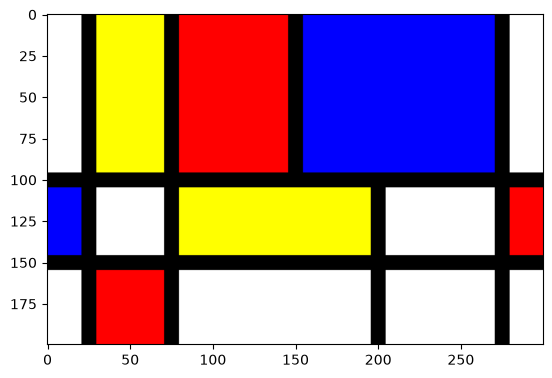

True

In [5]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
color_img[:,:] = 255

#Líneas negras verticales
cv2.line(color_img,(25,0),(25,alto),(0,0,0),7)
cv2.line(color_img,(75,0),(75,alto),(0,0,0),7)
cv2.line(color_img,(150,0),(150,int(alto/2)),(0,0,0),7)
cv2.line(color_img,(275,0),(275,alto),(0,0,0),7)
cv2.line(color_img,(200,int(alto/2)),(200, alto),(0,0,0),7)

#lineas negras horizontales
cv2.line(color_img,(0,100),(ancho,100),(0,0,0),7)
cv2.line(color_img,(0,150),(ancho,150),(0,0,0),7)

#Rectángulo relleno
cv2.rectangle(color_img,(30,95),(70,0),(255,255,0),-1)
cv2.rectangle(color_img,(80,95),(145,0),(255,0,0),-1)
cv2.rectangle(color_img,(155,95),(270,0),(0,0,255),-1)
cv2.rectangle(color_img,(0,145),(20,105),(0,0,255),-1)
cv2.rectangle(color_img,(80,145),(195,105),(255,255,0),-1)
cv2.rectangle(color_img,(280,145),(ancho,105),(255,0,0),-1)
cv2.rectangle(color_img,(30,alto),(70,155),(255,0,0),-1)

#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [6]:
vid = cv2.VideoCapture(0)

rad = 20
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        darker = [None, None, None] # promedio, x e y
        lighter = [None, None, None] # promedio, x e y

        alto, ancho, profundo = frame.shape

        for row in range(alto):
            for column in range(ancho):
                promedio = (int(frame[row, column, 0]) + int(frame[row, column, 1]) + int(frame[row, column, 2])) / 3

                if lighter[0] is None or lighter[0] < promedio:
                    lighter[0] = promedio
                    lighter[1] = row
                    lighter[2] = column

                if darker[0] is None or darker[0] > promedio:
                    darker[0] = promedio
                    darker[1] = row
                    darker[2] = column


        cv2.circle(frame,(darker[2], darker[1]), rad, (0,0,255), -1) # círculo rojo para más oscuro
        cv2.circle(frame,(lighter[2], lighter[1]), rad, (0,255,0), -1) # círculo verde para más claro

        cv2.imshow('Vid', frame)


    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

In [7]:
# forma optimizada por ChatGPT

vid = cv2.VideoCapture(0)

rad = 20

while True:
    ret, frame = vid.read()

    if not ret:
        break

    # Convertimos cada píxel a escala de grises
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Posición del píxel más oscuro y más claro
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gris)

    # Dibujamos los círculos
    cv2.circle(frame, min_loc, rad, (0, 0, 255), -1)  # rojo
    cv2.circle(frame, max_loc, rad, (0, 255, 0), -1)  # verde

    cv2.imshow('Vid', frame)

    if cv2.waitKey(1) == 27:
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h,w*2,3), dtype = np.uint8)
left = collage[0:h,0:w]
right = collage[0:h,w:w+w]

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        left[:,:,0] = g
        left[:,:,1] = b
        left[:,:,2] = 255-r

        right[:,:,0] = r
        right[:,:,1] = 225 - g
        right[:,:,2] = b
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

In [ ]:
# Ejercicio adicional
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h,w*2,3), dtype = np.uint8)
left = collage[0:h,0:w]
right = collage[0:h,w:w+w]

ncells = 10
off = int(ncells/2)

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        left[:,:,0] = g
        left[:,:,1] = b
        left[:,:,2] = 255-r

        right[:,:,0] = r
        right[:,:,1] = 225 - g
        right[:,:,2] = b

        #añadir puntitos

        down_right = cv2.resize(right, (int(w/ncells), int(h/ncells)), cv2.INTER_NEAREST)
        h2, w2, prof = down_right.shape
        for y in range(h2):
            for x in range(w2):
                cv2.circle(right,(x*ncells+off, y*ncells + off), 3, (0, 0, 139), -1)

        #añadir líneas
        # reusamos los valores calculados anteriormente

        ncells = 20

        for y in range(h2):
            for x in range(w2):
                cv2.line(left, (x*ncells+off, y*ncells + off), (x*ncells+off+w2, y*ncells + off+h2), (128, 0, 255), 2)



        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()